<a href="https://colab.research.google.com/github/hyesunyun/r-statistical-analysis-lab/blob/main/statistical_analysis_in_r_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Analysis in R

In this lab, we will go over descriptive statistics, hypothesis testing, and creating some simple graphs in R.

You can do all the things we will be covering in Python as well. For your project, feel free to use either R or Python for data analysis and creating charts and graphs.

In [ ]:
# Install packages
install.packages("DescTools") # for mode
install.packages("moments") # for skewness & kurtosis
install.packages("ggplot2") # for data viz
install.packages("dplyr") # for set of functions designed to enable dataframe manipulation in an intuitive, user-friendly way.
install.packages("datarium") # for the mice weight dataset
install.packages("pwr") # for power analysis
install.packages("effectsize") # for effect size calculations

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’




In [ ]:
# Import packages
library(DescTools)
library(moments)
library(ggplot2)
library(dplyr)
library(datarium)
library(pwr)
library(effectsize)

## Descriptive Statistics

Let's first load a dataset that we can use.

We will use the `mtcars` (Motor Trend Car Road Test) which is available as part of R's built-in datasets.

The data was extracted from the 1974 Motor Trend US magazine, and comprises fuel consumption and 10 aspects of automobile design and performance for 32 automobiles (1973-74 models)

In [ ]:
# Loading mtcars data
data(mtcars)

# Print the first 6 rows
head(mtcars, 6)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


In [ ]:
# Number of rows (observations)
nrow(mtcars)

[1] 32

In [ ]:
# Number of columns (variables)
ncol(mtcars)

[1] 11

In [ ]:
# To learn more about mtcars data set, type this:
# ?mtcars

### Measures of Center



*  Mode
*  Median
*  Mean

In R, the mode of a vector can be calculated using the `Mode()` function in the `DescTools` package. The function accepts a vector as an input and returns the most frequently occurring observation in the dataset.

If there are multiple modes, the Mode() function will return them as a vector.

In [ ]:
# mode of `cyl` or number of cylinder
Mode(mtcars$cyl)

[1] 8
attr(,"freq")
[1] 14

In R, the median of a vector is calculated using the median() function. If there are an odd number of values in the vector, the function returns the middle value. If there are an even number of values in the vector, the function returns the average of the two medians.

In [ ]:
# median `mpg` or miles per gallon
median(mtcars$mpg)

[1] 19.2

In R, the mean of a vector is calculated using the `mean()` function. The function accepts a vector as input, and returns the average as a numeric.

In [ ]:
# average of `mpg` or miles per gallon
mean(mtcars$mpg)

[1] 20.09062

### Measures of Spread


*   Standard Deviation
*   Variance
*   Inter-quartile Range
*   Range

The standard deviation and the variance is computed with the `sd()` and `var()` functions.

In [ ]:
sd(mtcars$mpg)

[1] 6.026948

In [ ]:
var(mtcars$mpg)

[1] 36.3241

The interquartile range (i.e., the difference between the first and third quartile) can be computed with the `IQR()` function

In [ ]:
IQR(mtcars$mpg)

[1] 7.375

The range can then be easily computed by subtracting the minimum from the maximum.

In [ ]:
# range
max(mtcars$mpg) - min(mtcars$mpg)

[1] 23.5

### Other Statistics Functions

*   summary()
*   table() - for contingency table



In [ ]:
# also can get minimum, 1st quartile, median, mean, 3rd quartile, and maximum using `summary()` function
summary(mtcars)

      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat             wt             qsec             vs        
 Min.   :2.760   Min.   :1.513   Min.   :14.50   Min.   :0.0000  
 1st Qu.:3.080   1st Qu.:2.581   1st Qu.:16.89   1st Qu.:0.0000  
 Median :3.695   Median :3.325   Median :17.71   Median :0.0000  
 Mean   :3.597   Mean   :3.217   Mean   :17.85   Mean   :0.4375  
 3rd Qu.:3.920   3rd Qu.:3.610   3rd Qu.:18.90   3rd Qu.:1.0000  
 Max.   :4.930   Max.   :5.424   Max.   :22.90   Max.   :1.0000  
       am              gear            carb      
 Min.   :0.0000   Min.   :3.000  

In [ ]:
# can also run summary for one vector
summary(mtcars$wt)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.513   2.581   3.325   3.217   3.610   5.424 

`table()` can be used on two qualitative variables to create a contingency table. A contingency table is a type of table in a matrix format that displays the multivariate frequency distribution of the variables.

For this example, we create the variable size which corresponds to `light` if the `wt` is smaller than the median of all cars, `heavy` otherwise. We also create the variable transmission which corresponds to `automatic` if `am` is 0 and `manual` if `am` = 1.

In [ ]:
mtcars$size <- ifelse(mtcars$wt < median(mtcars$wt),
  "light", "heavy"
)

In [ ]:
# add transmission column with "automatic" if am = 0, "manual" if am = 1
mtcars$transmission <- ifelse(mtcars$am == 0, "automatic", "manual")

In [ ]:
# Create a contingency table of the two variables size and transmission

table(mtcars$transmission, mtcars$size)

           
            heavy light
  automatic    15     4
  manual        1    12

In [ ]:
# relative frequencies
prop.table(table(mtcars$transmission))


automatic    manual 
  0.59375   0.40625 

In [ ]:
# relative frequencies by percent
round(100*prop.table(table(mtcars$transmission)), 1)


automatic    manual 
     59.4      40.6 

### Distribution Stats & Tests


*   Skewness
*   Kurtosis
*   Shapiro-Wilk test for non-normality



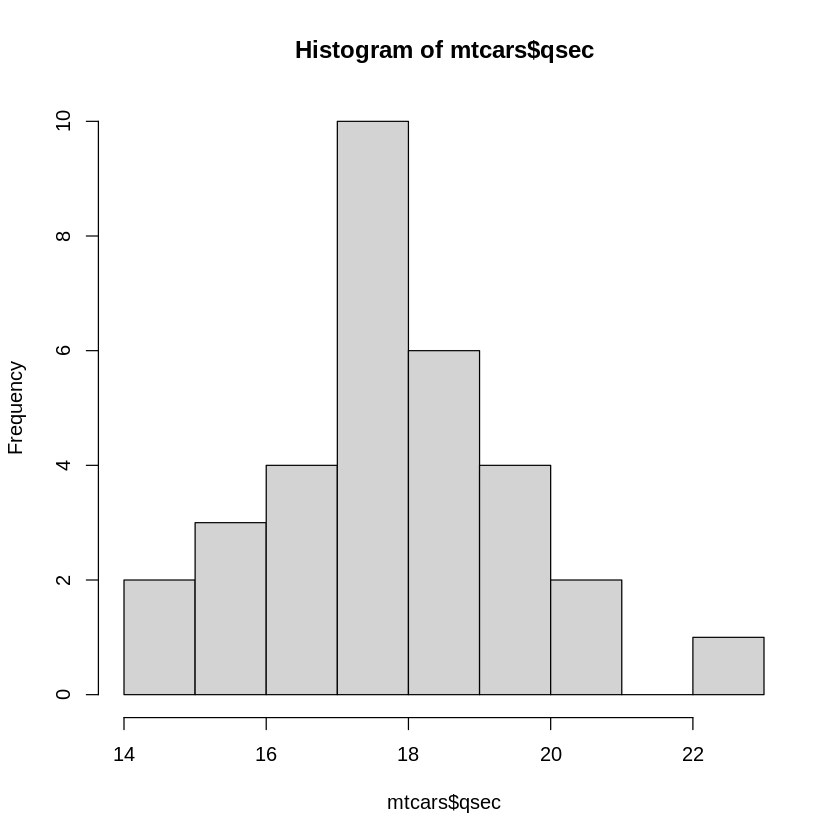

In [ ]:
# histogram of quarter mile time
hist(mtcars$qsec)

Skewness is a statistical numerical method to measure the asymmetry of the distribution or data set. It tells about the position of the majority of data values in the distribution around the mean value.


*   Positive Skewness (Right-Skewed): The tail on the right side of the distribution is longer or fatter. The mean is greater than the median.
*   Negative Skewness (Left-Skewed): The tail on the left side is longer or fatter. The mean is less than the median.
*   Zero Skewness (Symmetrical): The distribution is symmetrical, and the mean and median are equal.

In [ ]:
# < 0 for negative skew, > 0 for positive
skewness(mtcars$qsec)

[1] 0.3870456

In [ ]:
mean(mtcars$qsec)

[1] 17.84875

In [ ]:
median(mtcars$qsec)

[1] 17.71

Kurtosis indicates whether the distribution is too peaked or flat compared to a normal distribution. Positive kurtosis means a more peaked distribution, while negative kurtosis means a flatter one. A kurtosis greater than +2 suggests a too peaked distribution, while less than -2 indicates a too flat one.

In [ ]:
kurtosis(mtcars$qsec)

[1] 3.553753

To test if a data is normally distributed, we can use Shaprio Wilk test for non-normality. Shapiro-Wilk's method is widely recommended for normality test.

Note: Normality test is sensitive to sample size. Small samples most often pass normality tests.

In [ ]:
# if p <0.05, then non-normal
# if p >= 0.05, then data is normally distributed
shapiro.test(mtcars$qsec)


	Shapiro-Wilk normality test

data:  mtcars$qsec
W = 0.97325, p-value = 0.5935


### Data Visualizations
Adapted from https://libguides.princeton.edu/R-Visualization

Base R has some data visualization features.
We will also go over how to `ggplot2` which is a popular package for data visualization in R.

In this lab, we will cover the following basic data visualizations:

*   Line chart
*   Scatter plot
*   Histogram
*   Box plot
*   Bar plot

Also, using facets, groups, error bars.


#### Line Chart

We can plot trends over time or see the relationship between two variables.

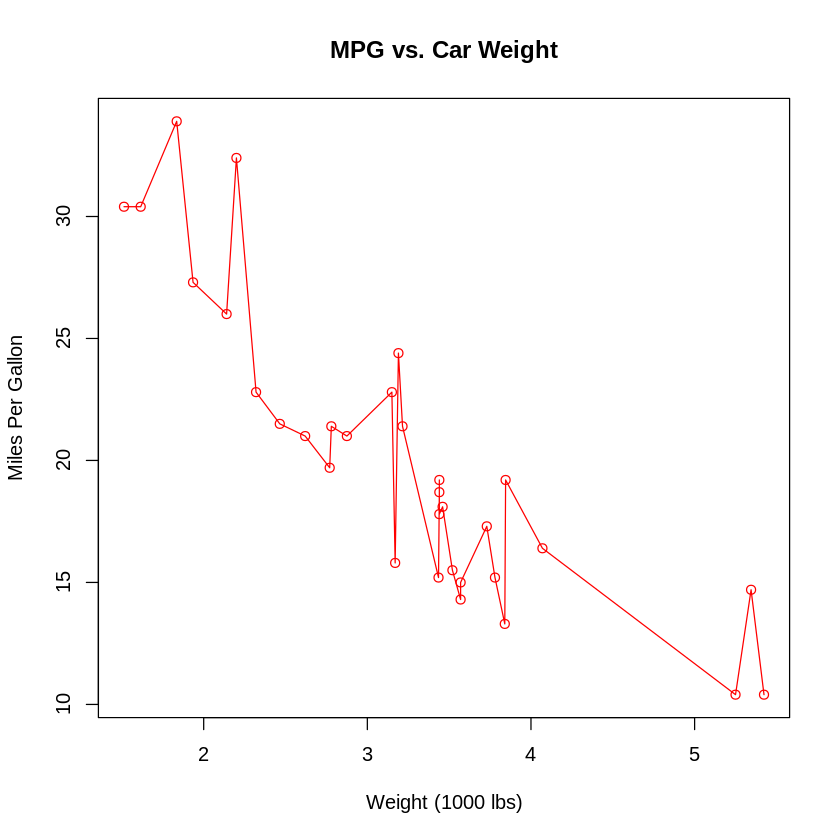

In [ ]:
# Sorting mtcars by wt
mtcars_sorted <- mtcars[order(mtcars$wt),]

# Base R
# Line graph showing MPG vs. Weight
plot(mtcars_sorted$wt, mtcars_sorted$mpg, type = "o", col = "red",
     xlab = "Weight (1000 lbs)", ylab = "Miles Per Gallon",
     main = "MPG vs. Car Weight")

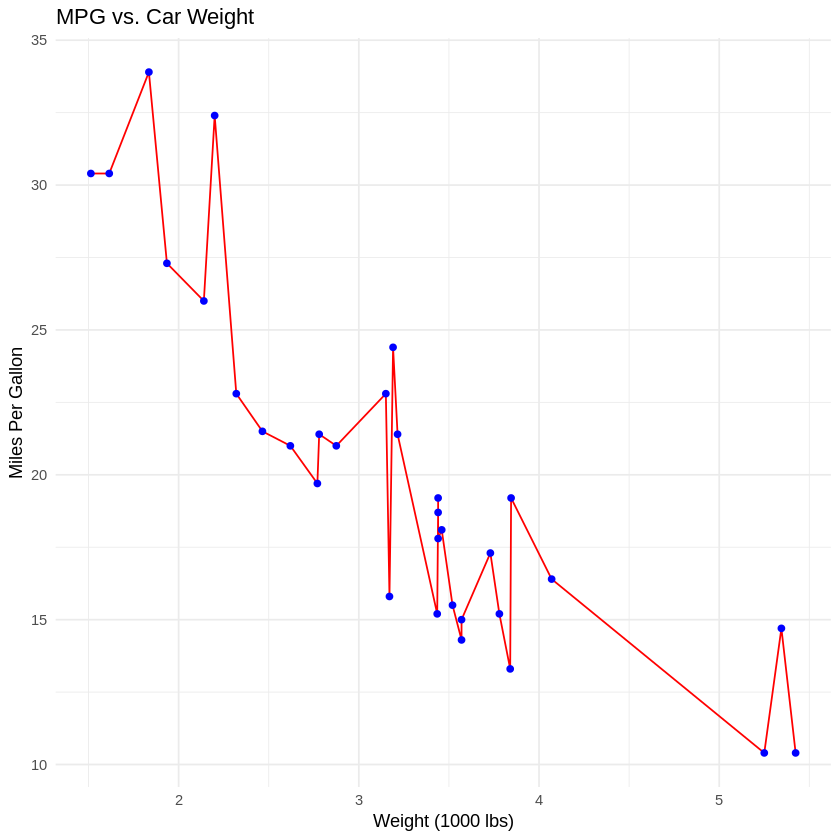

In [ ]:
# ggplot2
ggplot(mtcars, aes(x = wt, y = mpg)) +
  geom_line(aes(group = 1), color = "red") +  # Ensure a single group for the line
  geom_point(color = "blue") +
  theme_minimal() +
  labs(title = "MPG vs. Car Weight",
       x = "Weight (1000 lbs)",
       y = "Miles Per Gallon")

#### Scatter Plot

Scatter plots display values for two variables for a set of data so that we can get an idea of the trend or correlation. They can be useful for identifying correlations, trends, and outliers in data.

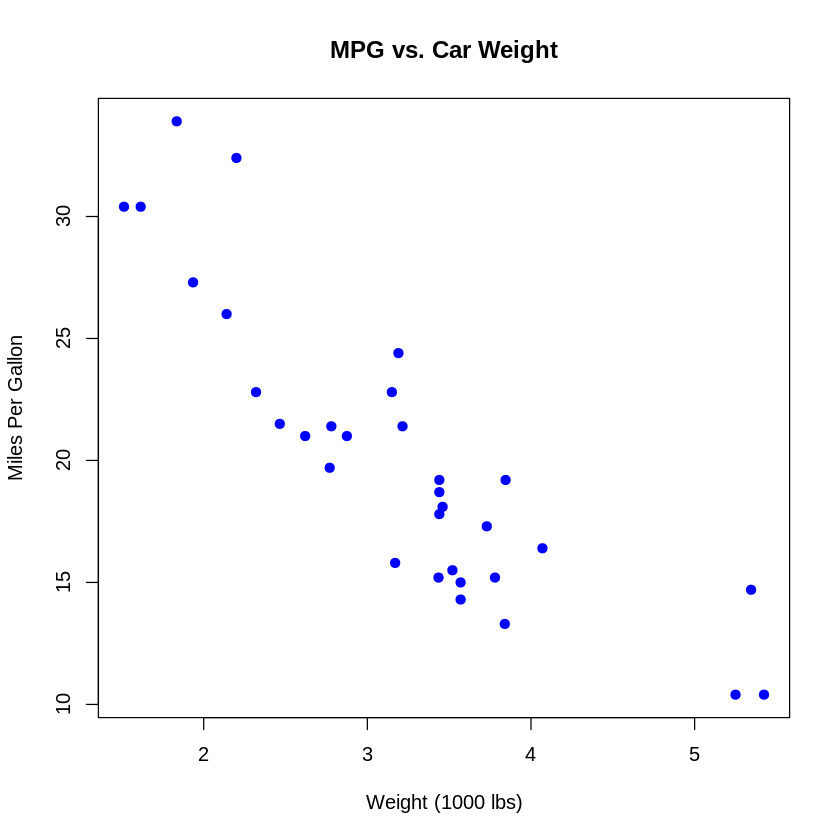

In [ ]:
#base R
# Scatter plot of MPG vs Weight
plot(mtcars$wt, mtcars$mpg,
     xlab = "Weight (1000 lbs)", ylab = "Miles Per Gallon",
     main = "MPG vs. Car Weight",
     pch = 19, col = "blue") # pch indicate the point shape. different numbers are for different shapes.

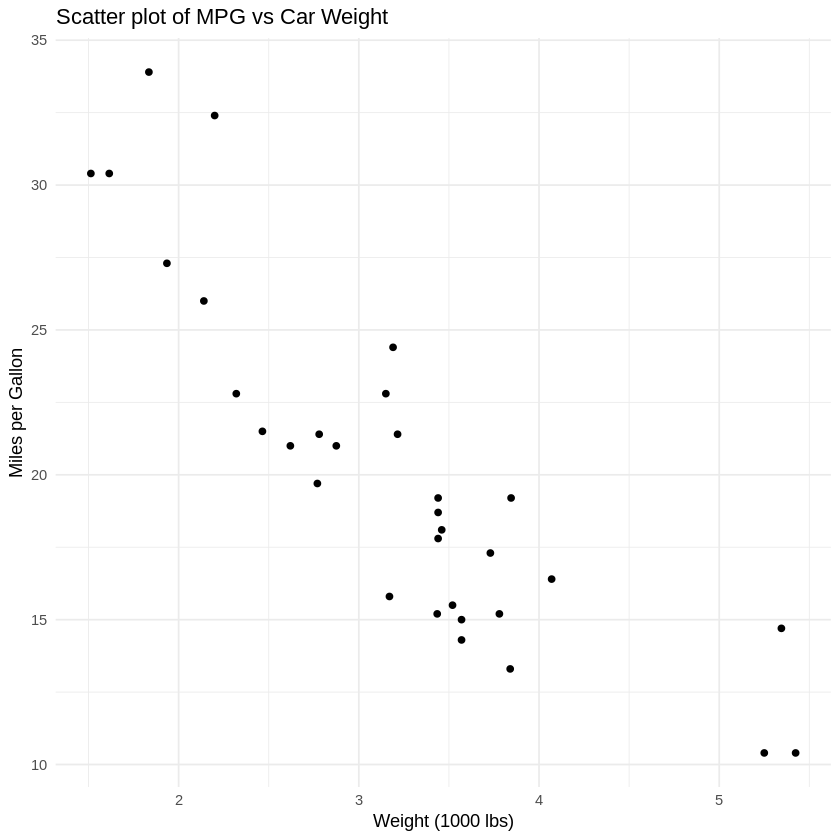

In [ ]:
ggplot(mtcars, aes(x = wt, y = mpg)) +
  geom_point() +
  theme_minimal() +
  labs(title = "Scatter plot of MPG vs Car Weight",
       x = "Weight (1000 lbs)",
       y = "Miles per Gallon")

#### Histogram

A histogram is a type of graph used in statistics to represent the distribution of numerical data by showing the number of data points that fall within a range of values, known as bins.

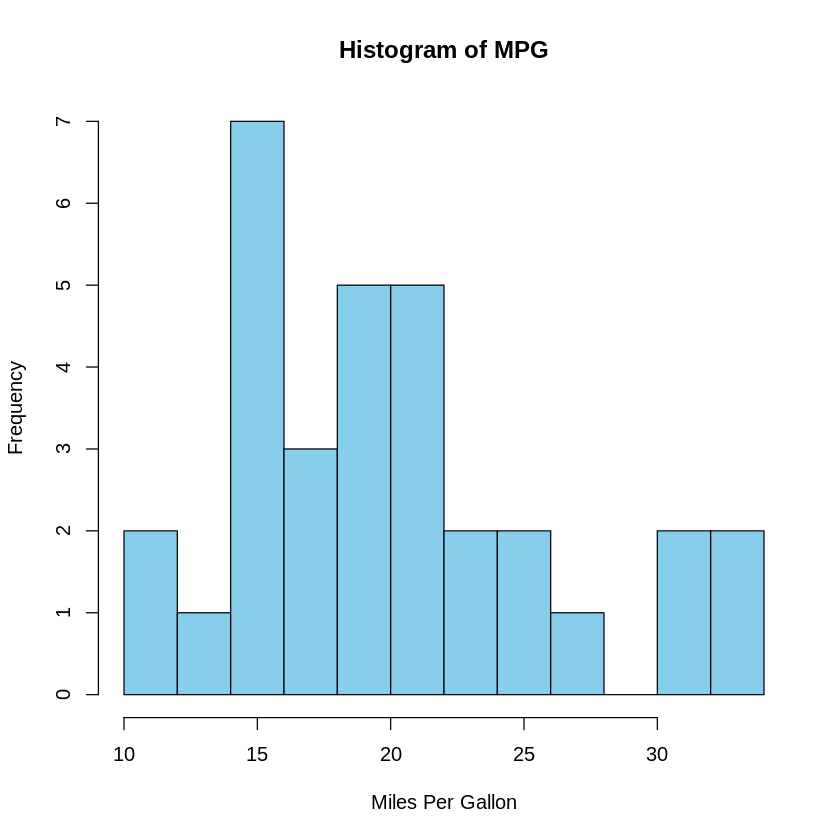

In [ ]:
# base R
# Histogram of MPG
# breaks control the number of bars, cells, or bins in histogram
hist(mtcars$mpg, breaks = 10, col = "skyblue",
     xlab = "Miles Per Gallon", main = "Histogram of MPG")

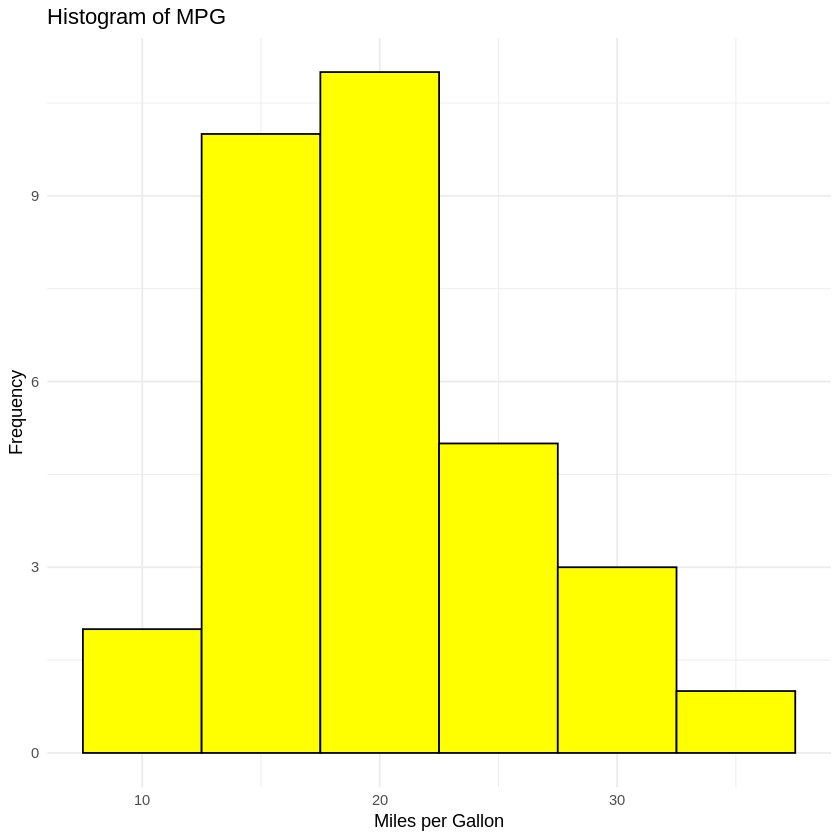

In [ ]:
# ggplot2
ggplot(mtcars, aes(x = mpg)) +
  geom_histogram(binwidth = 5, fill = "yellow", color = "black") +
  theme_minimal() +
  labs(title = "Histogram of MPG",
       x = "Miles per Gallon",
       y = "Frequency")

#### Box Plot

Box plots (or box-and-whisker plots) summarize data using a five-number summary: minimum, first quartile (Q1), median(not mean), third quartile (Q3), and maximum. They also highlight outliers.

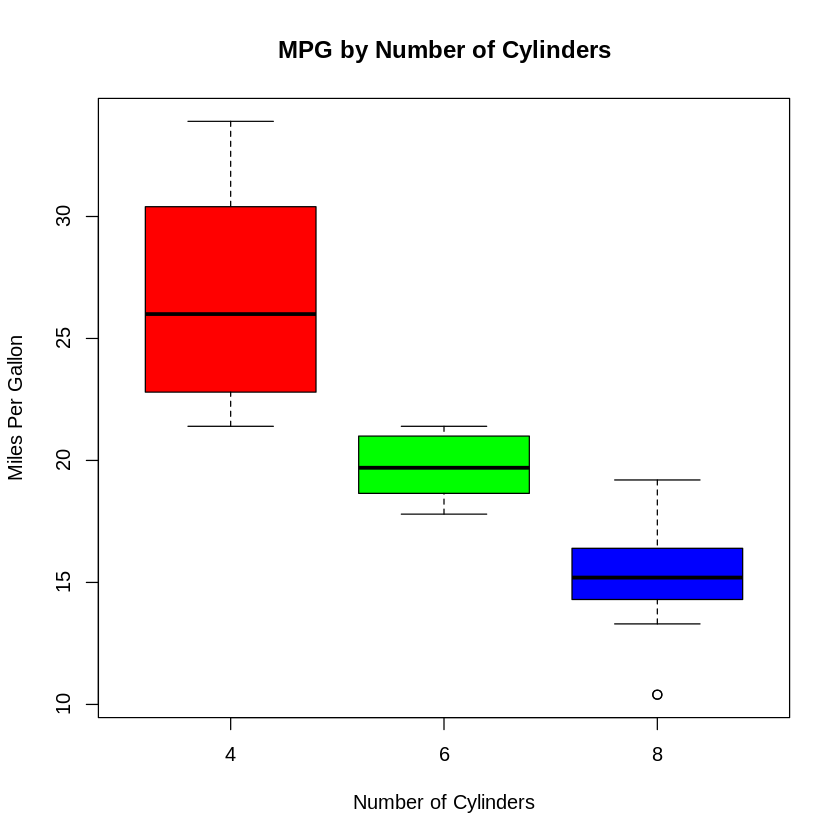

In [ ]:
# Box plot for MPG across different numbers of cylinders
# Convert cyl to a factor if it's not already
mtcars$cyl <- as.factor(mtcars$cyl)

# base R
# Box plot of MPG by number of cylinders
boxplot(mpg ~ cyl, data = mtcars,
        xlab = "Number of Cylinders", ylab = "Miles Per Gallon",
        main = "MPG by Number of Cylinders", col = rainbow(length(unique(mtcars$cyl))))

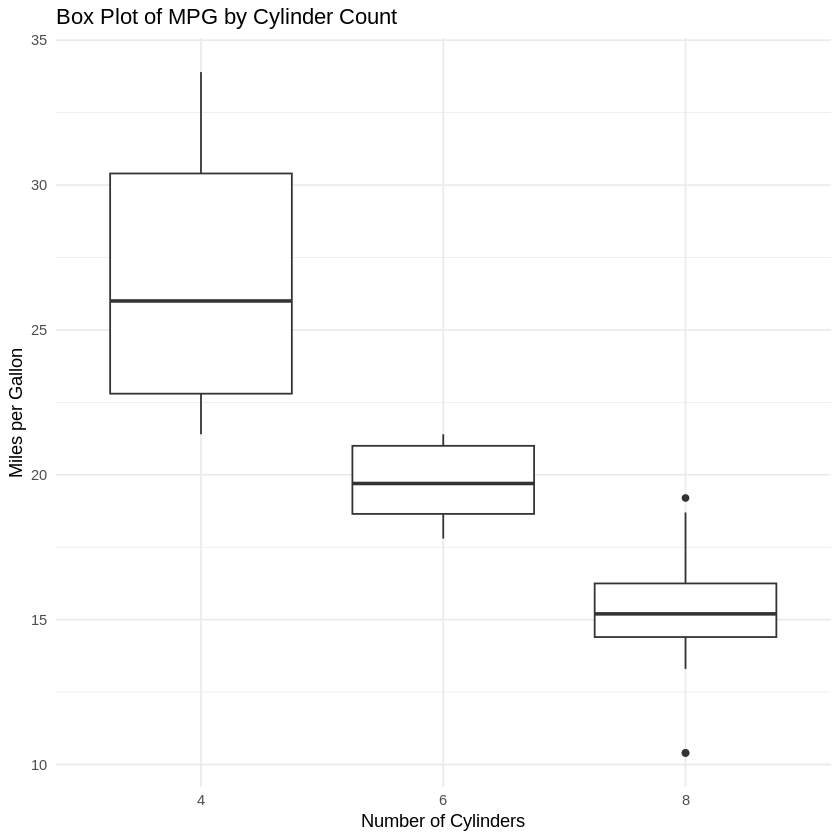

In [ ]:
# ggplot2
ggplot(mtcars, aes(x = factor(cyl), y = mpg)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Box Plot of MPG by Cylinder Count",
       x = "Number of Cylinders",
       y = "Miles per Gallon")

#### Faceted Plots

Faceted plots, or small multiples, divide data into subsets based on a categorical variable and plot each subset in its own panel. They use a consistent scale to facilitate direct comparison.

Faceting is powerful for comparing patterns across different levels of a categorical variable and for identifying how relationships between variables differ across subsets.

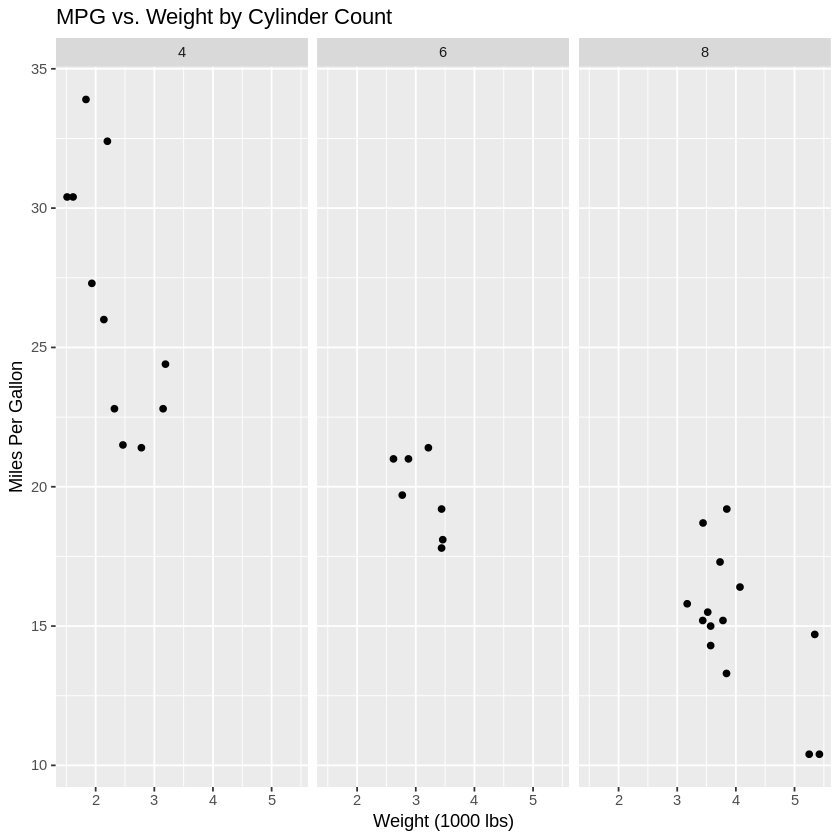

In [ ]:
# ggplot2
ggplot(mtcars, aes(wt, mpg)) +
  geom_point() +
  facet_wrap(~cyl) +
  labs(title = "MPG vs. Weight by Cylinder Count", x = "Weight (1000 lbs)", y = "Miles Per Gallon")

#### Plot different Groups

We can plot different groups together in one plot. We can use different colors to indicate different groups.

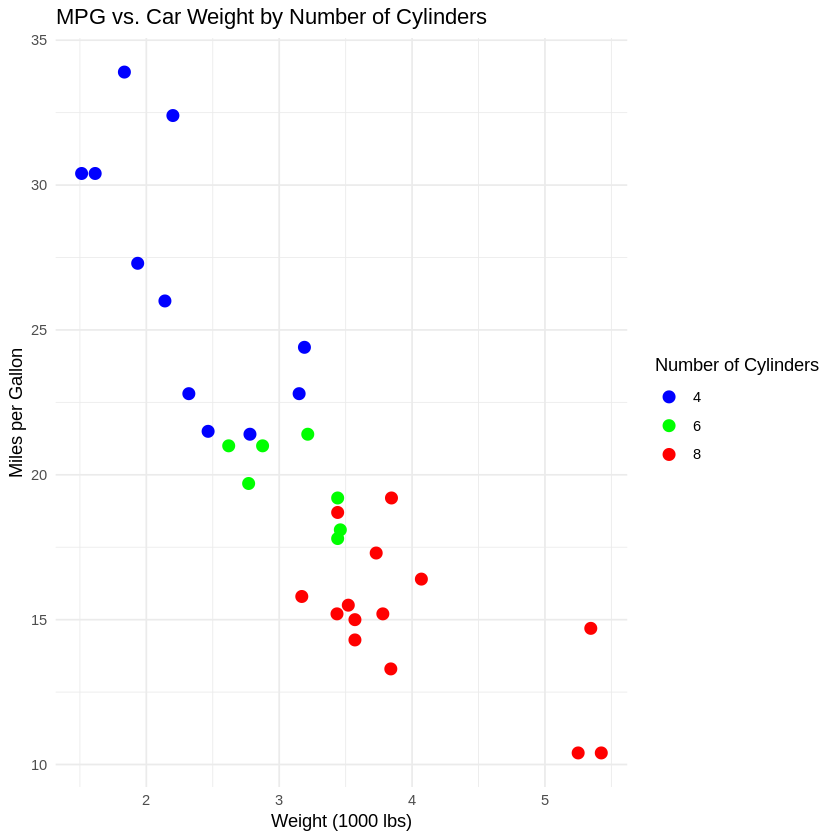

In [ ]:
# Convert cyl to a factor for color grouping
mtcars$cyl <- as.factor(mtcars$cyl)

# Plotting with ggplot2 by group (cyl) using color
ggplot(mtcars, aes(x = wt, y = mpg, color = cyl)) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(title = "MPG vs. Car Weight by Number of Cylinders",
       x = "Weight (1000 lbs)",
       y = "Miles per Gallon",
       color = "Number of Cylinders") +
  scale_color_manual(values = c("4" = "blue", "6" = "green", "8" = "red")) # Customize colors

We can also plot based on more than group: this is an example of bar plots based on different `cyl` and `gear` groups.

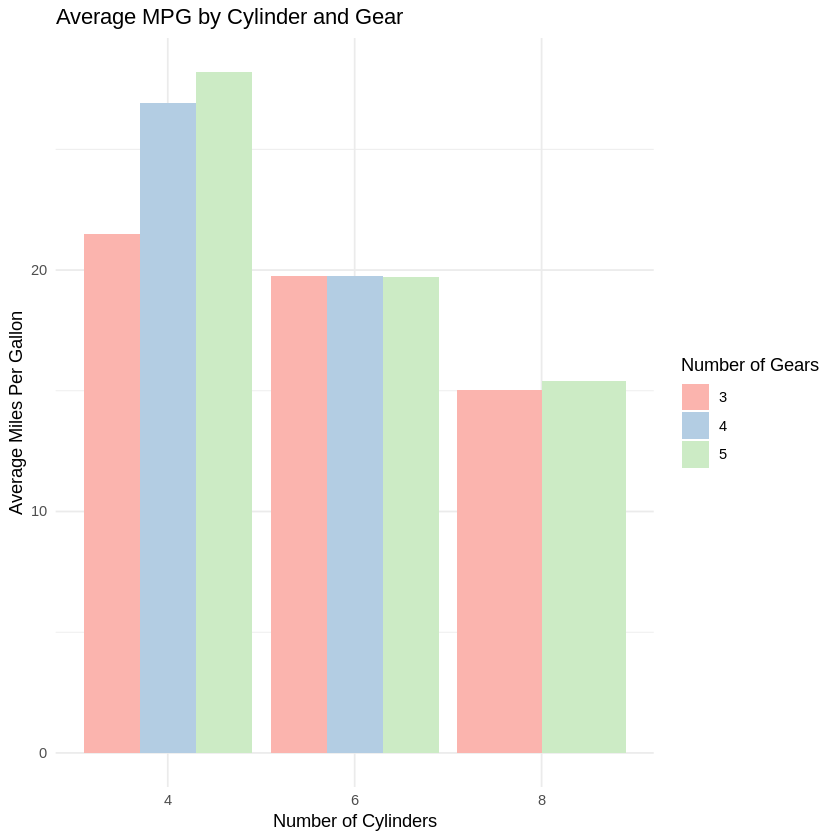

In [ ]:
# First, summarize the data
# %>% is a forward-pipe operator.
# You can use it to pass the left-had side input through the right-hand side operator
mtcars_summary <- mtcars %>%
  group_by(cyl, gear) %>%
  summarise(avg_mpg = mean(mpg), .groups = 'drop') %>%
  mutate(cyl = as.factor(cyl), gear = as.factor(gear)) # Ensure cyl and gear are treated as factors

# Now, create the bar plot
ggplot(mtcars_summary, aes(x = cyl, y = avg_mpg, fill = gear)) +
  geom_bar(stat = "identity", position = "dodge") +
  theme_minimal() +
  labs(title = "Average MPG by Cylinder and Gear",
       x = "Number of Cylinders",
       y = "Average Miles Per Gallon",
       fill = "Number of Gears") +
  scale_fill_brewer(palette = "Pastel1") # Use a color palette for better visual distinction



#### Error Bars

Bar plots of the average value of mpg in different groups, with error bars.
The use of error bars can indicate the variability or uncertainty in the data.

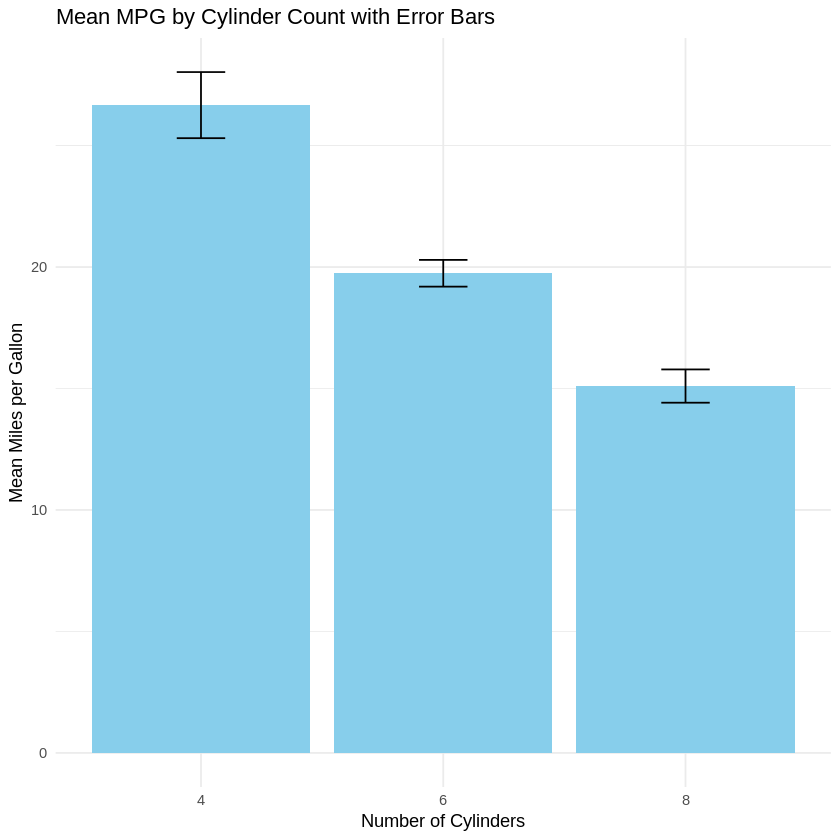

In [ ]:
# First, calculate means and standard deviations
mpg_summary <- mtcars %>%
  group_by(cyl) %>%
  summarise(mean_mpg = mean(mpg), sd_mpg = sd(mpg), se_mpg = sd_mpg / sqrt(n()))

# Bar plot for mean MPG with error bars (using standard error)
ggplot(mpg_summary, aes(x = factor(cyl), y = mean_mpg)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_errorbar(aes(ymin = mean_mpg - se_mpg, ymax = mean_mpg + se_mpg), width = .2) +
  theme_minimal() +
  labs(title = "Mean MPG by Cylinder Count with Error Bars",
       x = "Number of Cylinders",
       y = "Mean Miles per Gallon")

## Try it yourself!

TidyTuesday is a weekly social data project. They release a dataset each week for people to participate in data analysis.

We will use one of their datasets to practice statistical analysis.

### Taylor Swift Data
https://github.com/rfordatascience/tidytuesday/blob/main/data/2023/2023-10-17/readme.md

Taylor's entire discography can be found in taylor_all_songs. This includes all of the songs in taylor_album_songs plus EPs, individual singles, and the original versions of albums that have been re-released as Taylor's Version.

https://github.com/rfordatascience/tidytuesday/blob/main/data/2023/2023-10-17/readme.md#taylor_all_songscsv



In [ ]:
# Read directly from GitHub
taylor_all_songs <- readr::read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-17/taylor_all_songs.csv')

# for reading regular csv files in your local directory:
# data <- read.csv("path_to_csv_file/csv_file.csv")


Rows: 274 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (7): album_name, track_name, artist, featuring, key_name, mode_name, k...
dbl  (14): track_number, danceability, energy, key, loudness, mode, speechin...
lgl   (4): ep, bonus_track, explicit, lyrics
date  (4): album_release, promotional_release, single_release, track_release

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
head(taylor_all_songs)

album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,⋯,liveness,valence,tempo,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,lyrics
<chr>,<lgl>,<date>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<date>,<date>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<lgl>
Taylor Swift,FALSE,2006-10-24,1,Tim McGraw,Taylor Swift,NA,FALSE,NA,2006-06-19,⋯,0.1210,0.425,76.009,4,232107,FALSE,C,major,C major,NA
Taylor Swift,FALSE,2006-10-24,2,Picture To Burn,Taylor Swift,NA,FALSE,NA,2008-02-03,⋯,0.0962,0.821,105.586,4,173067,FALSE,G,major,G major,NA
Taylor Swift,FALSE,2006-10-24,3,Teardrops On My Guitar,Taylor Swift,NA,FALSE,NA,2007-02-19,⋯,0.1190,0.289,99.953,4,203040,FALSE,A#,major,A# major,NA
Taylor Swift,FALSE,2006-10-24,4,A Place In This World,Taylor Swift,NA,FALSE,NA,NA,⋯,0.3200,0.428,115.028,4,199200,FALSE,A,major,A major,NA
Taylor Swift,FALSE,2006-10-24,5,Cold As You,Taylor Swift,NA,FALSE,NA,NA,⋯,0.1230,0.261,175.558,4,239013,FALSE,F,major,F major,NA
Taylor Swift,FALSE,2006-10-24,6,The Outside,Taylor Swift,NA,FALSE,NA,NA,⋯,0.2400,0.591,112.982,4,207107,FALSE,F,major,F major,NA


In [ ]:
##### ADD CODE HERE #####
# how many rows are in the dataset?
print(nrow(taylor_all_songs))
# how many columns are in the dataset?
print(ncol(taylor_all_songs))

[1] 274
[1] 29


In [ ]:
##### ADD CODE HERE #####

# What is the mean and median of `danceability` of the songs?
# Spotify danceability score. A value of 0.0 is least danceable and 1.0 is most danceable.
# hint: make sure to add na.rm = TRUE in the function to remove any NA's

cat("Mean danceability:", mean(taylor_all_songs$danceability, na.rm = TRUE), "\n")
cat("Median danceability:", median(taylor_all_songs$danceability, na.rm = TRUE), "\n")
# or
print(summary(taylor_all_songs$danceability))

Mean danceability: 0.5865513 
Median danceability: 0.598 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.2920  0.5135  0.5980  0.5866  0.6535  0.8970      11 


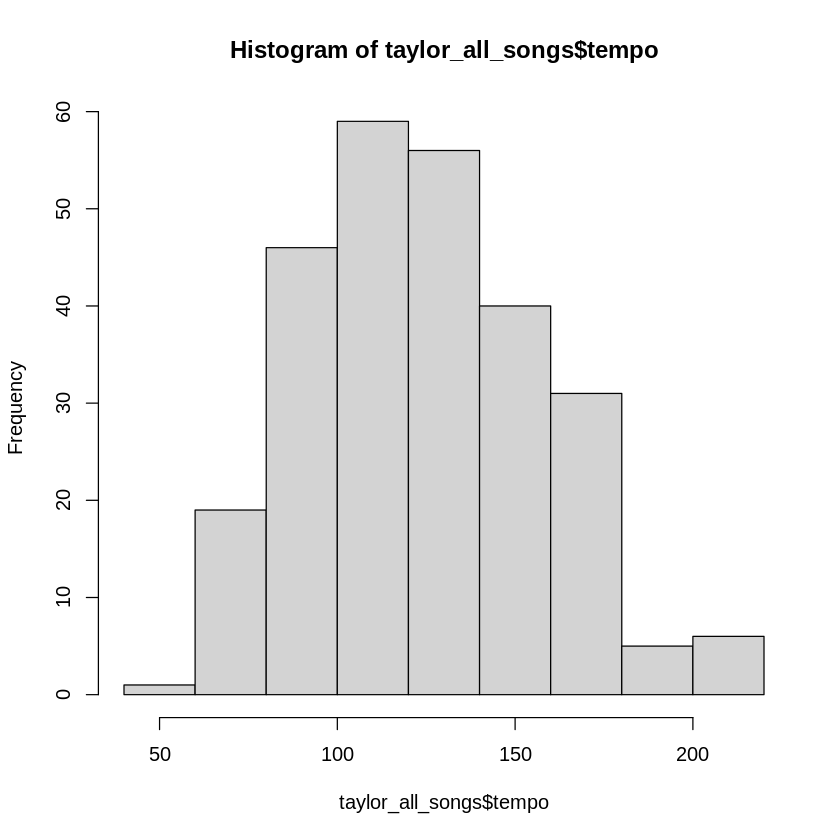

In [ ]:
##### ADD CODE HERE #####

# Create a histogram for `tempo` to view the distribution of data
# `tempo` is the overall estimated tempo of a track in beats per minute (BPM).

hist(taylor_all_songs$tempo)

In [ ]:
##### ADD CODE HERE #####

# What is the skewness of duration_ms?
# does it have positive skewness, negative skewness?
# hint: add na.rm = TRUE

skewness(taylor_all_songs$duration_ms, na.rm = TRUE)

[1] 2.671959

In [ ]:
# find the count of rows grouped by `key_name` using dplyr's `group_by()` function

group_by(taylor_all_songs, key_name) %>%
  summarise(count = n())

key_name,count
<chr>,<int>
A,19
A#,10
B,8
C,44
C#,12
D,29
D#,5
E,32
F,31


In [ ]:
##### ADD CODE HERE #####
# What is the mean and sd of `valence` grouped by `key_name` using `group_by()`?
# Spotify valence score. A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track.
# Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric),
# while tracks with low valence sound more negative (e.g. sad, depressed, angry).

group_by(taylor_all_songs, key_name) %>%
  summarise(
    mean = mean(valence, na.rm = TRUE),
    sd = sd(valence, na.rm = TRUE)
  )

key_name,mean,sd
<chr>,<dbl>,<dbl>
A,0.4114684,0.2234257
A#,0.4638400,0.2127161
B,0.4112500,0.1848264
C,0.3515091,0.1881224
C#,0.3962500,0.1881794
D,0.3735172,0.1753455
D#,0.4350000,0.1713184
E,0.3828250,0.2072877
F,0.4712258,0.1461138


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


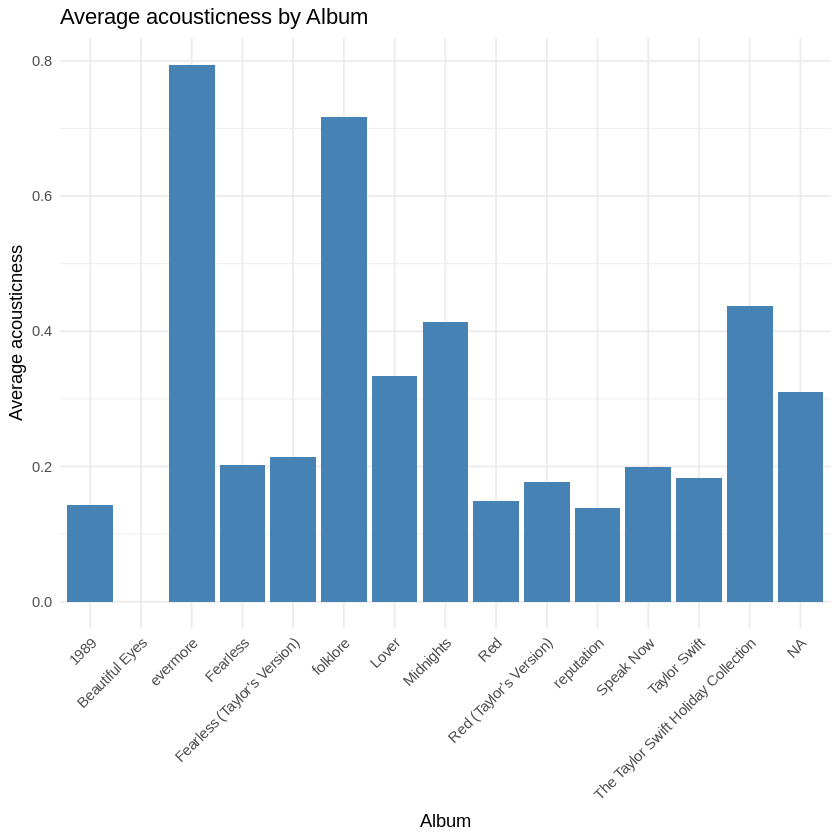

In [ ]:
##### ADD CODE HERE #####

# Create a bar chart looking at average `acousticness` by `album_name`

# Aggregate data
avg_acousticness <- taylor_all_songs %>%
  group_by(album_name) %>%
  summarise(avg_acousticness = mean(acousticness, na.rm = TRUE))

# Create bar chart
ggplot(avg_acousticness, aes(x = as.factor(album_name), y = avg_acousticness)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "Average acousticness by Album",
       x = "Album",
       y = "Average acousticness") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels if needed


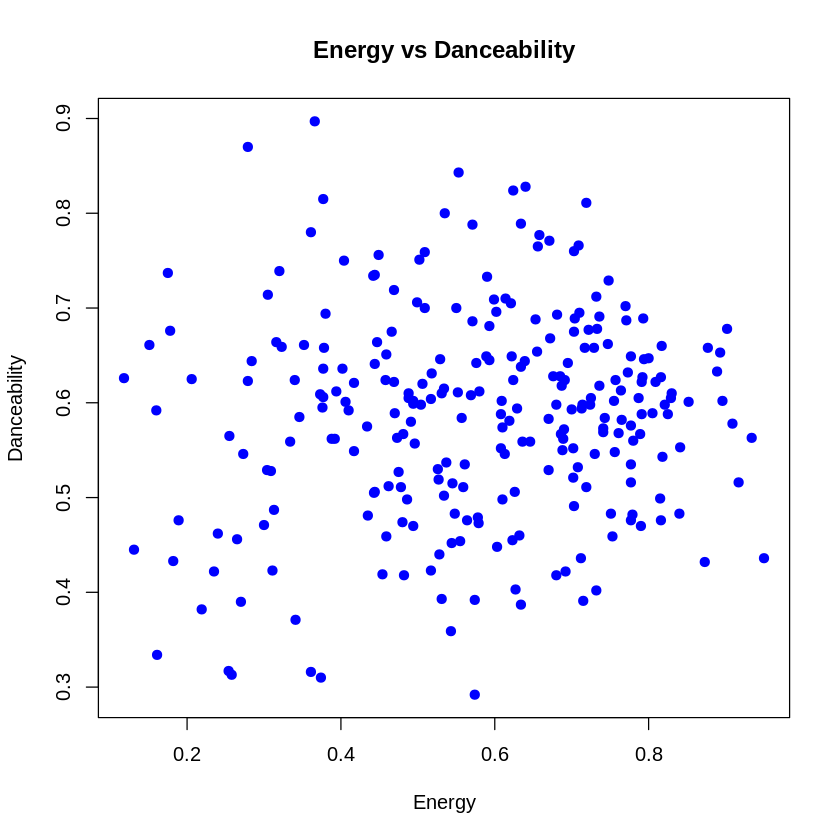

In [ ]:
##### ADD CODE HERE #####

# create a scatter plot looking at `energy` and `danceability`
# Spotify energy score. Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.

#base R
plot(taylor_all_songs$energy, taylor_all_songs$danceability,
     xlab = "Energy", ylab = "Danceability",
     main = "Energy vs Danceability",
     pch = 19, col = "blue")

# ggplot(taylor_all_songs, aes(x = energy, y = danceability)) +
  # geom_point() +
  # theme_minimal() +
  # labs(title = "Scatter plot of Energy vs Danceability",
  #      x = "Energy",
  #      y = "Danceability")


In [ ]:
##### ADD CODE HERE #####

# Create a data visualization of your choice below:

## Hypothesis Testing

*   one-sample t Test
*   two-sample t Test (paired and unpaired)
*   ANOVA

The selection depends on data type, distribution, sample size, and whether the hypothesis is one-tailed or two-tailed.

In this lab, we will only cover hypothesis tests for normally distributed data (Shapiro-Wilk test can show this). These tests are called parametric tests.

If your data is not normally distributed, you can run the non-parametric equivalent versions of the tests such as Chi Square Test, Wilcoxon Test, Mann Whitney Test.

### T-Test

The t-test is one of the most common hypothesis tests in statistics. The t-test determines either whether the sample mean and the mean of the population differ or if two sample means differ statistically. The t-test distinguishes between"

* one sample t-test
* independent sample t-test
* paired samples t-test

#### One sample t-test

We use the one sample t-test when we want to compare the mean of a sample with a known reference mean.

Image Credit: https://datatab.net/tutorial/t-test

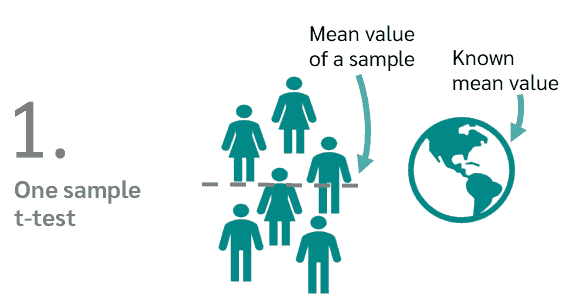

In [ ]:
# Sample data of 10 mice with different weights
data(mice)
head(mice, 3)

name,weight
<chr>,<dbl>
M_1,18.9
M_2,19.5
M_3,23.1


In [ ]:
# Compute some summary statistics: count (number of subjects), mean and sd (standard deviation)
print(mean(mice$weight))
print(sd(mice$weight))

[1] 20.14
[1] 1.896312


In [ ]:
# Known population mean
pop_mean <- 25

# Perform one-sample t-test
result <- t.test(mice$weight, mu = pop_mean)

# Display the result
print(result)


	One Sample t-test

data:  mice$weight
t = -8.1045, df = 9, p-value = 1.995e-05
alternative hypothesis: true mean is not equal to 25
95 percent confidence interval:
 18.78346 21.49654
sample estimates:
mean of x 
    20.14 



#### t-test for independent samples

We use the t-test for independent samples when we want to compare the means of two independent groups or samples. We want to know if there is a significant difference between these means.

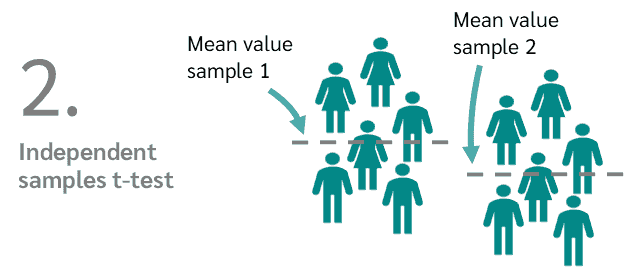

In [ ]:
# we’ll use an example data set, which contains the weight of 18 individuals (9 women and 9 men):
women_weight <- c(38.9, 61.2, 73.3, 21.8, 63.4, 64.6, 48.4, 48.8, 48.5)
men_weight <- c(67.8, 60, 63.4, 76, 89.4, 73.3, 67.3, 61.3, 62.4)

# Create a data frame
my_data <- data.frame(
                group = rep(c("Woman", "Man"), each = 9),
                weight = c(women_weight,  men_weight)
                )
print(my_data)

   group weight
1  Woman   38.9
2  Woman   61.2
3  Woman   73.3
4  Woman   21.8
5  Woman   63.4
6  Woman   64.6
7  Woman   48.4
8  Woman   48.8
9  Woman   48.5
10   Man   67.8
11   Man   60.0
12   Man   63.4
13   Man   76.0
14   Man   89.4
15   Man   73.3
16   Man   67.3
17   Man   61.3
18   Man   62.4


In [ ]:
group_by(my_data, group) %>%
  summarise(
    count = n(),
    mean = mean(weight, na.rm = TRUE),
    sd = sd(weight, na.rm = TRUE)
  )

group,count,mean,sd
<chr>,<int>,<dbl>,<dbl>
Man,9,68.98889,9.375426
Woman,9,52.10000,15.596714


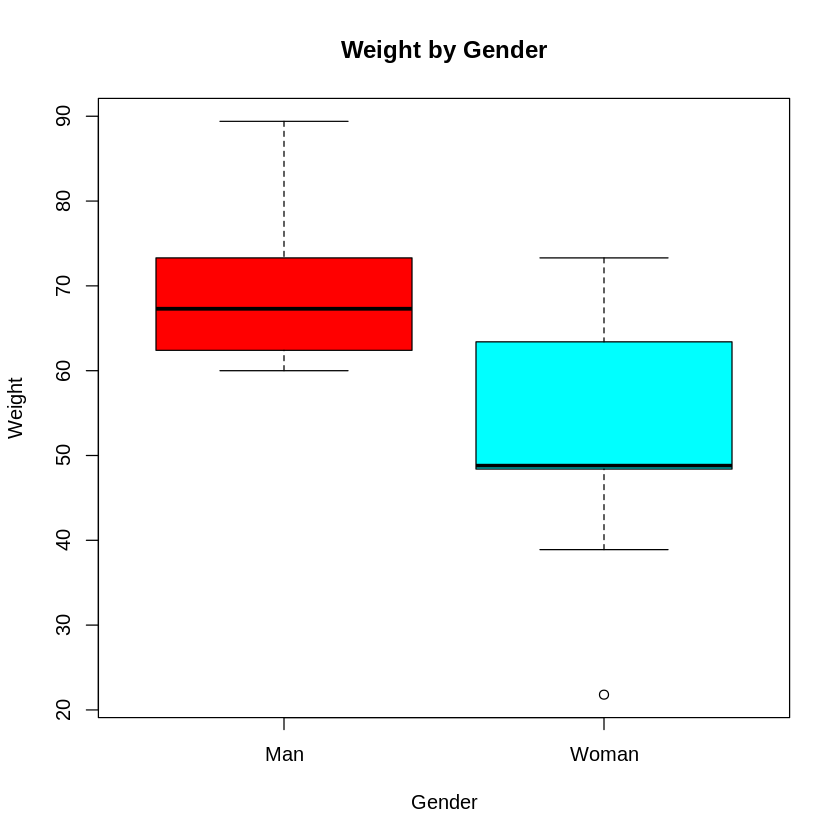

In [ ]:
# Plot weight by group and color by group
boxplot(weight ~ group, data = my_data,
        xlab = "Gender", ylab = "Weight",
        main = "Weight by Gender", col = rainbow(length(unique(my_data$group))))

In [ ]:
# Compute t-test
res <- t.test(women_weight, men_weight, var.equal = TRUE)
res


	Two Sample t-test

data:  women_weight and men_weight
t = -2.7842, df = 16, p-value = 0.01327
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -29.748019  -4.029759
sample estimates:
mean of x mean of y 
 52.10000  68.98889 


#### Paired samples t-test

The t-test for dependent samples is used to compare the means of two dependent groups. In a dependent sample (paired sample), the measured values are available in pairs. The pairs are created, for example, by repeated measurements on the same persons.

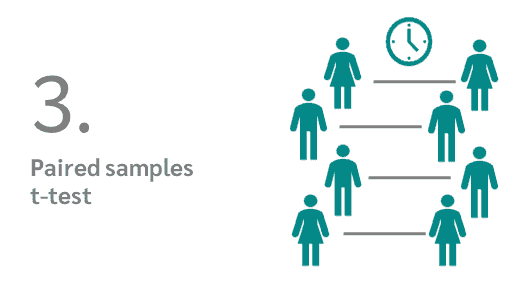

In [ ]:
# Data in two numeric vectors
# ++++++++++++++++++++++++++
# Weight of the mice before treatment
before <-c(200.1, 190.9, 192.7, 213, 241.4, 196.9, 172.2, 185.5, 205.2, 193.7)
# Weight of the mice after treatment
after <-c(392.9, 393.2, 345.1, 393, 434, 427.9, 422, 383.9, 392.3, 352.2)
# Create a data frame
my_data <- data.frame(
                group = rep(c("before", "after"), each = 10),
                weight = c(before,  after)
                )

print(my_data)

    group weight
1  before  200.1
2  before  190.9
3  before  192.7
4  before  213.0
5  before  241.4
6  before  196.9
7  before  172.2
8  before  185.5
9  before  205.2
10 before  193.7
11  after  392.9
12  after  393.2
13  after  345.1
14  after  393.0
15  after  434.0
16  after  427.9
17  after  422.0
18  after  383.9
19  after  392.3
20  after  352.2


In [ ]:
group_by(my_data, group) %>%
  summarise(
    count = n(),
    mean = mean(weight, na.rm = TRUE),
    sd = sd(weight, na.rm = TRUE)
  )

group,count,mean,sd
<chr>,<int>,<dbl>,<dbl>
after,10,393.65,29.39801
before,10,199.16,18.47354


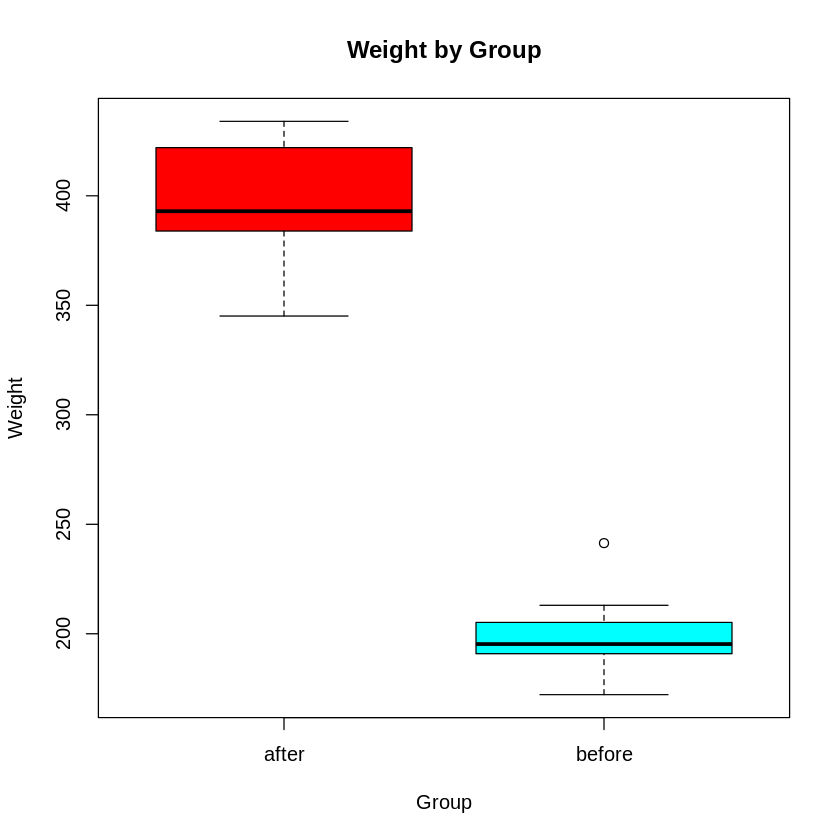

In [ ]:
# Plot weight by group and color by group
boxplot(weight ~ group, data = my_data,
        xlab = "Group", ylab = "Weight",
        main = "Weight by Group", col = rainbow(length(unique(my_data$group))))

In [ ]:
# Compute t-test, paired = TRUE
res <- t.test(before, after, paired = TRUE)
res


	Paired t-test

data:  before and after
t = -20.883, df = 9, p-value = 6.2e-09
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -215.5581 -173.4219
sample estimates:
mean difference 
        -194.49 


### Analysis of Variance (ANOVA)

An analysis of variance (ANOVA) tests whether statistically significant differences exist between more than two samples. For this purpose, the means and variances of the respective groups are compared with each other. In contrast to the t-test, which tests whether there is a difference between two samples, the ANOVA tests whether there is a difference between more than two groups.

You can have one-way ANOVA or two-way ANOVA.
The one-way analysis of variance only checks whether an independent variable has an influence on a metric dependent variable.
However, if two factors, i.e. two independent variables, are considered, a two-way analysis of variance must be used.

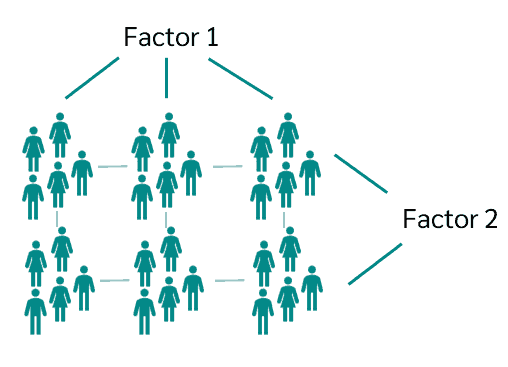


**One-way ANOVA	Example**

Does a person's place of residence (independent variable) influence his or her salary?

**Two-way ANOVA	Example**

Does a person's place of residence (1st independent variable) and gender (2nd independent variable) affect his or her salary?



In [ ]:
# we will go over one-way ANOVA example:

data(PlantGrowth)

# Show a random sample
set.seed(1234)
dplyr::sample_n(PlantGrowth, 10)

weight,group
<dbl>,<fct>
6.15,trt2
3.83,trt1
5.29,trt2
5.12,trt2
4.50,ctrl
4.17,trt1
5.87,trt1
5.33,ctrl
5.26,trt2


In [ ]:
# compute summary statistics by groups - count, mean, sd
group_by(PlantGrowth, group) %>%
  summarise(
    count = n(),
    mean = mean(weight, na.rm = TRUE),
    sd = sd(weight, na.rm = TRUE)
  )

group,count,mean,sd
<fct>,<int>,<dbl>,<dbl>
ctrl,10,5.032,0.5830914
trt1,10,4.661,0.7936757
trt2,10,5.526,0.4425733


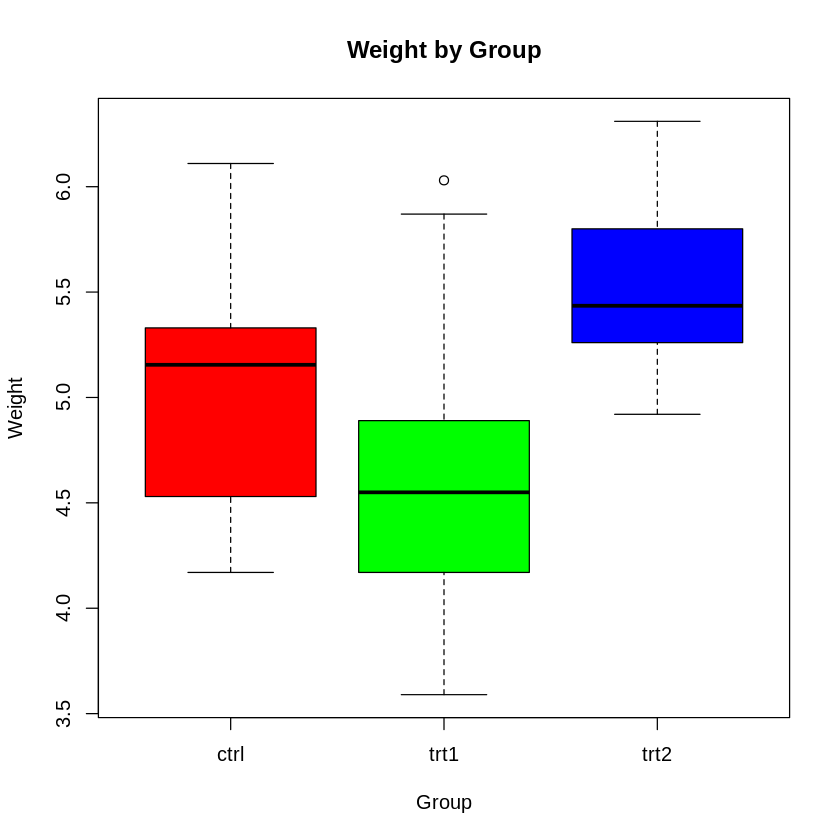

In [ ]:
# Plot weight by group and color by group
boxplot(weight ~ group, data = PlantGrowth,
        xlab = "Group", ylab = "Weight",
        main = "Weight by Group", col = rainbow(length(unique(PlantGrowth$group))))

In [ ]:
# Compute the analysis of variance
res.aov <- aov(weight ~ group, data = PlantGrowth)
# Summary of the analysis
summary(res.aov)

            Df Sum Sq Mean Sq F value Pr(>F)  
group        2  3.766  1.8832   4.846 0.0159 *
Residuals   27 10.492  0.3886                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# As the ANOVA test is significant, we can compute Tukey HSD (Tukey Honest Significant Differences, R function: TukeyHSD())
# for performing multiple pairwise-comparison between the means of groups.
# The function TukeyHD() takes the fitted ANOVA as an argument.

TukeyHSD(res.aov)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = weight ~ group, data = PlantGrowth)

$group
            diff        lwr       upr     p adj
trt1-ctrl -0.371 -1.0622161 0.3202161 0.3908711
trt2-ctrl  0.494 -0.1972161 1.1852161 0.1979960
trt2-trt1  0.865  0.1737839 1.5562161 0.0120064


For details on two-way ANOVA test, please refer: https://www.sthda.com/english/wiki/two-way-anova-test-in-r

## Power Analysis

https://www.datacamp.com/doc/r/power

Power analysis is an important aspect of experimental design. It allows us to determine the sample size required to detect an effect of a given size with a given degree of confidence. Conversely, it allows us to determine the probability of detecting an effect of a given size with a given level of confidence, under sample size constraints. If the probability is unacceptably low, we would be wise to alter or abandon the experiment.

**This can be done during data analysis or can be done during the study design phase if you are trying to determine the size of your sample.**

The following four quantities have an intimate relationship:

1.   sample size
2.   effect size
3.   significance level = P(Type I error) = probability of finding an effect that is not there. often the default is 0.05.
4.   power = 1 - P(Type II error) = probability of finding an effect that is there

*Given any three, we can determine the fourth.*

The [pwr package](https://cran.r-project.org/web/packages/pwr/pwr.pdf) develped by Stéphane Champely, impliments power analysis as outlined by Cohen (1988).

Here are some of the more important functions from the package.

| **function** | **power calculations for** |
|---|---|
| pwr.p.test | proportion (one sample) |
| pwr.t.test | t-tests (one sample, 2 sample, paired) |
| pwr.t2n.test | t-test (two samples with unequal n) |
| pwr.anova.test | balanced one way ANOVA |
| pwr.r.test | correlation |

For each of these functions, you enter three of the four quantities (effect size, sample size, significance level, power) and the fourth is calculated.

The **significance level defaults to 0.05**. Therefore, to calculate the significance level, given an effect size, sample size, and power, use the option "sig.level=NULL".

Specifying an **effect size** can be a daunting task. Cohen's suggestions (based on social science research) are provided below, but they should only be seen as a very rough estimate. Your own subject matter experience should be brought to bear and also results from previous studies or pilot studies can be useful.

### Power Calculation

**What is the power of a two-tailed two-sample t-test, with a significance level of 0.05, 19 in one group, and 13 in another group?**

First, let's fit a simple two sample t-test using the mtcars data to explore mean MPG for both transmission groups (AM).

In [ ]:
t <- t.test(mpg ~ am, data = mtcars)

#### t-tests

For t-tests, use the following functions:

**pwr.t.test(n = , d = , sig.level = , power = , type = c("two.sample", "one.sample", "paired"))**

where n is the sample size, d is the effect size, and type indicates a two-sample t-test, one-sample t-test or paired t-test. If you have unequal sample sizes, use

**pwr.t2n.test(n1 = , n2= , d = , sig.level =, power = )**

where n1 and n2 are the sample sizes.

Cohen suggests that d values of 0.2, 0.5, and 0.8 represent small, medium, and large effect sizes respectively.

You can specify alternative="two.sided", "less", or "greater" to indicate a two-tailed, or one-tailed test. A two tailed test is the default.

We will use the `pwr.t2n.test()` function.
However, we will need to first calculate Cohen's `d` via `effectsize`

In [ ]:
# Note, when using the formula interface to t.test(), this method (currently) only gives an approximate effect size.
# So for this first simple approach, we update our test (t_alt) and then make a call to effectsize().

t_alt <- t.test(mtcars$mpg[mtcars$am == 0], mtcars$mpg[mtcars$am == 1])

effectsize(t_alt, type = "cohens_d")

,Cohens_d,CI,CI_low,CI_high
,<dbl>,<dbl>,<dbl>,<dbl>
difference in means,-1.411046,0.95,-2.260021,-0.5342256


In [ ]:
# effectsize supports many different indices
# if we are using cohen's d, then we can just call `cohens_d` method.

d <- cohens_d(mpg ~ am, data = mtcars)
d

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-1.477947,0.95,-2.265973,-0.6705684


Now we are ready to calculate the statistical power of our t-test given that we have collected the essential ingredients.

In [ ]:
Ns <- table(mtcars$am)

pwr.t2n.test(
  n1 = Ns[1], n2 = Ns[2],
  d = d[["Cohens_d"]],
  sig.level = 0.05,
  alternative = "two.sided"
)


     t test power calculation 

             n1 = 19
             n2 = 13
              d = 1.477947
      sig.level = 0.05
          power = 0.9778637
    alternative = two.sided


The results tell us that we are sufficiently powered, with a very high power for each group, 0.978. The power value is between 0 and 1.

If you were to change the group sample sizes to something very small, say n = c(2, 2), then you would get a much lower power, suggesting that your sample size is too small to detect any reliable signal or to be able to trust your results.

### Sample Size Calculation

Let's try finding the appropriate sample size for a given power and effect size.

For a one-way ANOVA comparing 5 groups, calculate the
sample size needed in each group to obtain a power of 0.80, when the effect size is moderate (0.25) and a significance level of 0.05 is employed.

In [ ]:
pwr.anova.test(k=5,f=.25,sig.level=.05,power=.8)


     Balanced one-way analysis of variance power calculation 

              k = 5
              n = 39.1534
              f = 0.25
      sig.level = 0.05
          power = 0.8

NOTE: n is number in each group


How about a one-way ANOVA comparing 3 groups?

Calculate the sample size needed in each group to obtain a power of 0.80 when effect size is 0.50 and significance level is 0.05.

In [ ]:
##### ADD CODE HERE #####

pwr.anova.test(k=3,f=.5,sig.level=.05,power=.8)


     Balanced one-way analysis of variance power calculation 

              k = 3
              n = 13.89521
              f = 0.5
      sig.level = 0.05
          power = 0.8

NOTE: n is number in each group


How about a two-sample t-test?

Calculate the sample size (equal) needed in each group to obtain a power of 0.80 when effect size is 0.30 and significance level is 0.05.

In [ ]:
##### ADD CODE HERE #####

pwr.t.test(d=0.3, sig.level=0.05, power=0.80, type="two.sample")


     Two-sample t test power calculation 

              n = 175.3847
              d = 0.3
      sig.level = 0.05
          power = 0.8
    alternative = two.sided

NOTE: n is number in *each* group


## Resources


* A meta resource with links to additional learning resources for R programming, IDEs, data analysis and visualization with R, etc:  https://paulvanderlaken.com/2017/08/10/r-resources-cheatsheets-tutorials-books/
* A detailed no-nonsense tutorial for R beginners, from the author of the "The R Inferno": https://www.burns-stat.com/documents/tutorials/impatient-r/
* Training website on data science which contains many toturials on data analysis and visualization using R software and packages: https://www.sthda.com/english/
* Data Visualization resource: https://r-graph-gallery.com/
* Data visualization with - ggplot2: https://ggplot2.tidyverse.org/reference/


